# Imports

In [1]:
import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt

from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration

In [2]:
h = .02

moll_eps = 4 * h**(.99)
delta = 45 * h**(.99)

# Parameter used in Navier-Stokes equation
nu = .0005

t_step = .05
t_max = 12.5

# Parameters for random blob methods
alg = 2
num_batches = 2
ratio = 2

# Function Definitions


In [3]:
def grad_V(x, y):
    return 0

# Distribution of our initial data
def rho_0(x, y):
    return max([0, 1 - 4 * (np.abs(x) - .5)**2 - 4 * y**2])**7 / 0.19634954083

# 2nd derivative of Moreau-Yosida envelope
def f_double_prime_epsilon(x):
    return nu * x**(-1)
    
def g(r):
    r = r / delta

    return np.where(r >= 1, 1, 560 * r**26 - 5915 * r**24 
                    + 28392 * r**22 - 81796 * r**20 
                    + 157300 * r**18 - 212355 * r**16 
                    + 205920 * r**14 - 144144 * r**12
                    + 72072 * r**10 - 25025 * r**8
                    + 5720 * r**6 - 780 * r**4 
                    + 52 * r**2)


# Particle Method

In [4]:
def initial_data():
   points_x = np.array([])
   points_y = np.array([])
   m_vals = np.array([])

   rad_delta = h
   
   rad_vals = np.arange(0, .5, rad_delta)
   x_centers = [.5, -.5]

   def func(r, theta):
      x = r * np.cos(theta)
      y = r * np.sin(theta)
      return r * rho_0(x - x_centers[0], y)

   for rad in rad_vals:
      if rad == 0:
         weight = integrate.dblquad(func, 0, 2 * np.pi, 0, rad_delta / 2)[0]

         points_x = np.append(points_x, x_centers[0])
         points_y = np.append(points_y, 0)
         m_vals = np.append(m_vals, weight)

         points_x = np.append(points_x, x_centers[1])
         points_y = np.append(points_y, 0)
         m_vals = np.append(m_vals, weight)
         
      else: 
         theta_vals = np.linspace(0, 2 * np.pi, int(2.5 * np.pi * rad / rad_delta))
         theta_delta = theta_vals[1]
         weight = integrate.dblquad(func, 0, theta_delta, rad - rad_delta / 2, rad + rad_delta / 2)[0]
         for theta in theta_vals:
            points_x = np.append(points_x, rad * np.cos(theta) + x_centers[0])
            points_y = np.append(points_y, rad * np.sin(theta))
            m_vals = np.append(m_vals, weight)

            points_x = np.append(points_x, rad * np.cos(theta) + x_centers[1])
            points_y = np.append(points_y, rad * np.sin(theta))
            m_vals = np.append(m_vals, weight)

   m_vals = m_vals / sum(m_vals)

   mask = m_vals != 0
   points_x = points_x[mask]
   points_y = points_y[mask]
   m_vals = m_vals[mask]

   # Remove possible duplicates
   pairs = np.stack((points_x, points_y), axis=1)
   _, unique_indices = np.unique(pairs, axis=0, return_index=True)
   unique_indices = np.sort(unique_indices)
   points_x = points_x[unique_indices]
   points_y = points_y[unique_indices]
   m_vals = m_vals[unique_indices]

   return points_x, points_y, m_vals
   

# Plot

In [5]:
def plot(part_sol):
    N = int(part_sol[0, :].size / 2)
    x0 = part_sol[0, :N]
    y0 = part_sol[0, N:]

    x_centers = [.5, -.5]
    if h == .025:
        targets = np.array([.475, .35, .225, .1])
    if h == .02:
        targets = np.array([.48, .36, .24, .12])
    if h == .015:
        targets = np.array([.48, .36, .24, .12])

    dist_to_neg2 = np.sqrt((x0 + x_centers[0])**2 + (y0)**2)
    dist_to_pos2 = np.sqrt((x0 + x_centers[1])**2 + (y0)**2)

    red_distance_mask = np.isclose(dist_to_neg2[:, None], targets, atol=1e-5).any(axis=1)
    red_indices = np.where(red_distance_mask)[0]

    blue_distance_mask = np.isclose(dist_to_pos2[:, None], targets, atol=1e-5).any(axis=1)
    blue_indices = np.where(blue_distance_mask)[0]

    count = 5
    for i in np.linspace(0, part_sol[:, 1].size - 1, 4):
        i = int(i)
        print(i * .05)
        plt.scatter(part_sol[i, red_indices], part_sol[i, x0.size + red_indices], color = 'red', s=10)
        plt.scatter(part_sol[i, blue_indices], part_sol[i, x0.size + blue_indices], color = 'blue', s=10)
        plt.xlim(-1.5, 1.5)
        plt.ylim(-1.5, 1.5)
        plt.gca().set_aspect('equal', adjustable='box')

        plt.rcParams.update({'font.size': 20})
        plt.rcParams['text.usetex'] = True
        plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
        plt.show()

        count += 1


# Main


N = 4688.


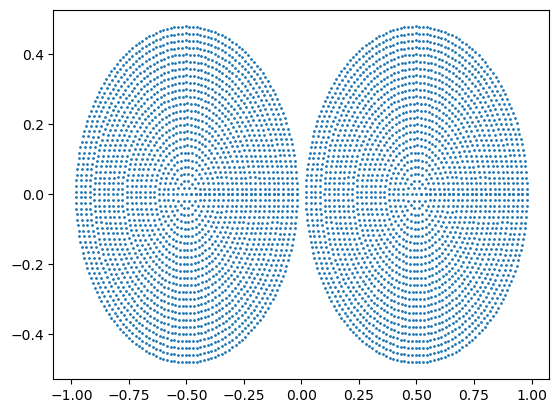

In [6]:
x0, y0, m_vals = initial_data()
print("N = " + str(m_vals.size) + ".")
plt.scatter(x0, y0, s=1)
plt.show()

In [ ]:
particle_sol, runtime = solve_ODE(x0, y0, m_vals, alg, num_batches, ratio, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max, True, g) 
plot(particle_sol)

Time step 1.
Time step 2.
Time step 3.
Time step 4.
Time step 5.
Time step 6.
Time step 7.
Time step 8.
Time step 9.
Time step 10.
Time step 11.
Time step 12.
Time step 13.
Time step 14.
Time step 15.
Time step 16.
Time step 17.
Time step 18.
Time step 19.
Time step 20.
Time step 21.
Time step 22.
Time step 23.
Time step 24.
Time step 25.
Time step 26.
Time step 27.
Time step 28.
Time step 29.
Time step 30.
Time step 31.
Time step 32.
Time step 33.
Time step 34.
Time step 35.
Time step 36.
Time step 37.
Time step 38.
Time step 39.
Time step 40.
Time step 41.
Time step 42.
Time step 43.
Time step 44.
Time step 45.
Time step 46.
Time step 47.
Time step 48.
Time step 49.
Time step 50.
Time step 51.
Time step 52.
Time step 53.
Time step 54.
Time step 55.
Time step 56.
Time step 57.
Time step 58.
Time step 59.
Time step 60.
Time step 61.
Time step 62.
Time step 63.
Time step 64.
Time step 65.
Time step 66.
Time step 67.
Time step 68.
Time step 69.
Time step 70.
Time step 71.
Time step 72.
T

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

0.0


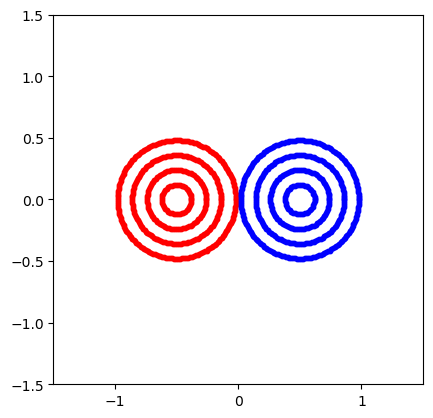

4.15


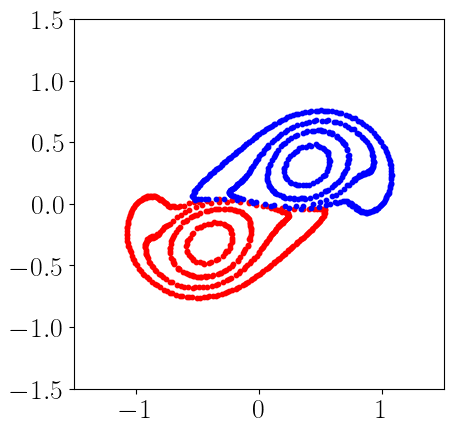

8.3


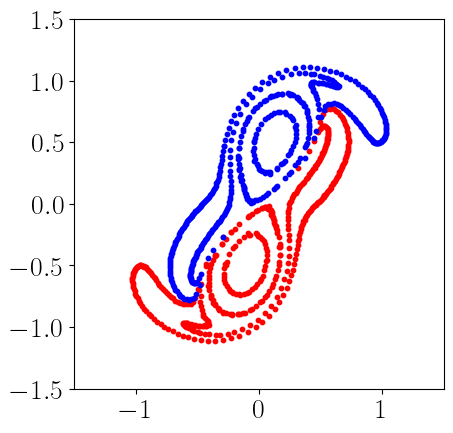

12.5


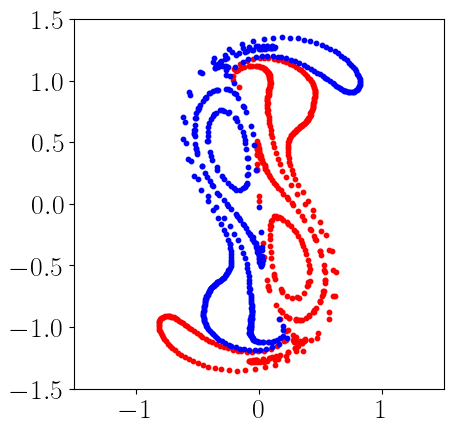

In [8]:
plot(particle_sol)